In [1]:
import os
import glob
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
%matplotlib inline


In [2]:
df = pd.read_csv('train.csv')
df.head()

,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0


In [3]:
base_dir = "colored_images"

#### Checking distribution of all 4 classes

Class counts:
 diagnosis
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64


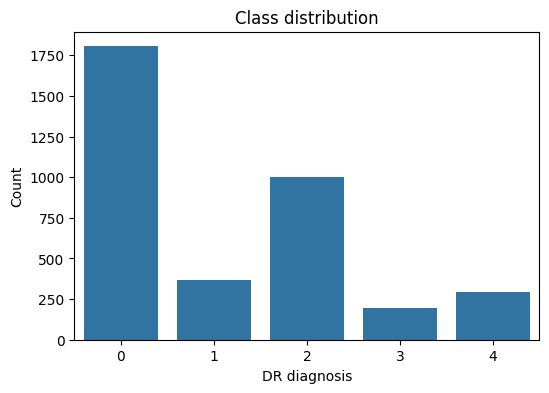

In [4]:
# 3. Check class distribution
counts = df['diagnosis'].value_counts().sort_index()
print("Class counts:\n", counts)
plt.figure(figsize=(6,4))
sns.barplot(x=counts.index, y=counts.values)
plt.title("Class distribution")
plt.xlabel("DR diagnosis")
plt.ylabel("Count")
plt.show()

#### Checking for Missing Values

In [5]:
label_map = {
    0: "No_DR",
    1: "Mild",
    2: "Moderate",
    3: "Severe",
    4: "Proliferate_DR"
}

missing = []
for _, row in df.iterrows():
    label_folder = label_map[row["diagnosis"]]
    found = os.path.exists(os.path.join(base_dir, label_folder, f"{row['id_code']}.png"))

    if not found:
        missing.append(row["id_code"])

print(f"Missing {len(missing)} images.")

Missing 0 images.


#### Preview of Images

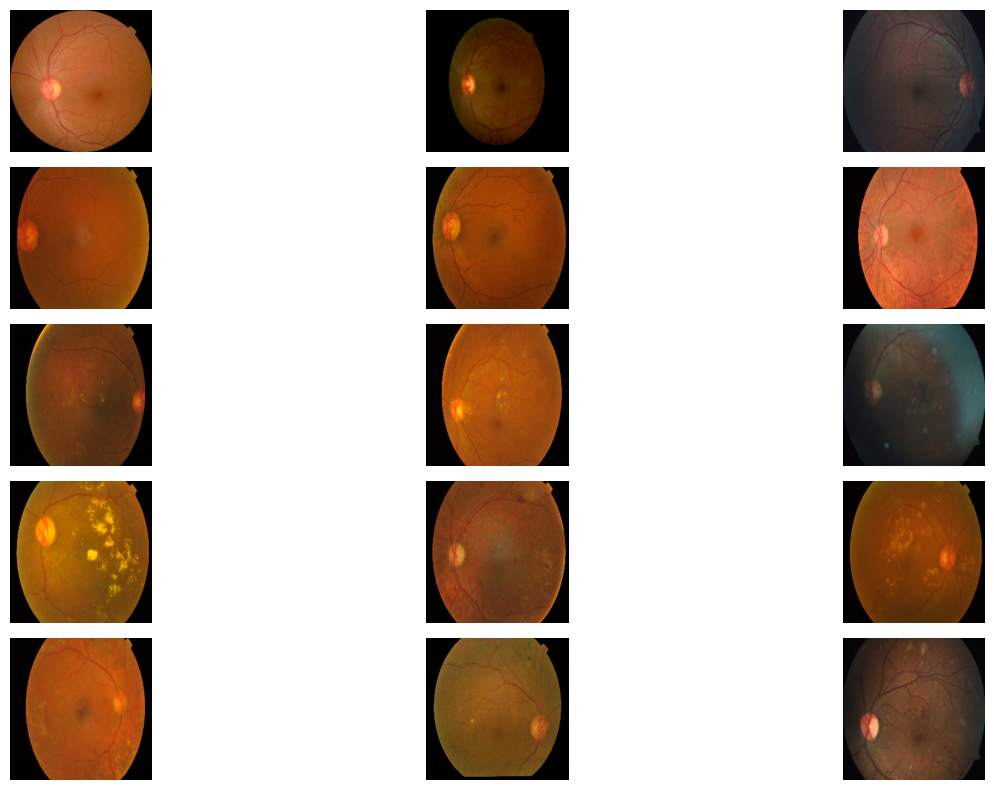

In [6]:
import cv2
import matplotlib.pyplot as plt

label_map = {0:"No_DR", 1:"Mild", 2:"Moderate", 3:"Severe", 4:"Proliferate_DR"}
def show_samples_per_class(n=3):
    plt.figure(figsize=(15,8))
    for label, folder in label_map.items():
        img_files = os.listdir(os.path.join(base_dir, folder))[:n]
        for i, img_file in enumerate(img_files):
            img_path = os.path.join(base_dir, folder, img_file)
            img = cv2.imread(img_path)
            if img is None: continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            plt.subplot(len(label_map), n, label*n + i + 1)
            plt.imshow(img)
            plt.axis("off")
            if i == 1:
                plt.ylabel(folder, fontsize=12)
    plt.tight_layout()
    plt.show()

show_samples_per_class(3)


In [6]:
label_map = {
    0: "No_DR",
    1: "Mild",
    2: "Moderate",
    3: "Severe",
    4: "Proliferate_DR"
}

df['image_path'] = df.apply(
    lambda row: os.path.join(base_dir, label_map[row['diagnosis']], f"{row['id_code']}.png"),
    axis=1
)
print(df.head())

        id_code  diagnosis                                      image_path
0  000c1434d8d7          2        colored_images\Moderate\000c1434d8d7.png
1  001639a390f0          4  colored_images\Proliferate_DR\001639a390f0.png
2  0024cdab0c1e          1            colored_images\Mild\0024cdab0c1e.png
3  002c21358ce6          0           colored_images\No_DR\002c21358ce6.png
4  005b95c28852          0           colored_images\No_DR\005b95c28852.png


In [7]:
from sklearn.model_selection import train_test_split

# Create stratified train / validation / test splits:
# We want: test = 10% of full dataset, val = 20% of full dataset, train = remaining 70%
test_size = 0.10  # 10% hold-out test set
val_size = 0.20   # 20% validation set (of the whole dataset)

# 1) split off test set
temp_df, test_df = train_test_split(df, test_size=test_size, stratify=df['diagnosis'], random_state=42)

# 2) from remaining data, split train and val so that val is val_size of the original dataset
val_prop = val_size / (1.0 - test_size)  # proportion of temp_df that should become validation
train_df, val_df = train_test_split(temp_df, test_size=val_prop, stratify=temp_df['diagnosis'], random_state=42)

print(f"Counts -> train: {len(train_df)}, val: {len(val_df)}, test: {len(test_df)}")
print(f"Fractions -> train: {len(train_df)/len(df):.3f}, val: {len(val_df)/len(df):.3f}, test: {len(test_df)/len(df):.3f}")

Counts -> train: 2562, val: 733, test: 367
Fractions -> train: 0.700, val: 0.200, test: 0.100


In [8]:
image_size = (224, 224)
batch_size = 32

#### Data Augmentation

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col='image_path',
    y_col='diagnosis',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='raw',
    color_mode='rgb'
)

val_gen = val_datagen.flow_from_dataframe(
    val_df,
    x_col='image_path',
    y_col='diagnosis',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='raw',
    color_mode='rgb'
)


Found 2562 validated image filenames.
Found 733 validated image filenames.


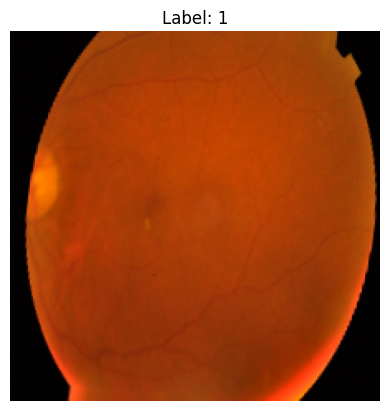

In [8]:
batch = next(iter(train_gen))
images, labels = batch

plt.imshow(images[0])
plt.title(f"Label: {int(labels[0])}")
plt.axis('off')
plt.show()


#### Building simple CNN

In [10]:
from tensorflow.keras import layers, models

def small_cnn(input_shape=(224, 224, 3), num_classes=5):
    inp = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, (3, 3), activation='relu')(inp)
    x = layers.MaxPool2D()(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.MaxPool2D()(x)
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    
    return models.Model(inputs=inp, outputs=out)
    

In [11]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(train_df['diagnosis'])
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_df['diagnosis']
)

class_weights = dict(zip(classes, class_weights))
print(class_weights)

{0: 0.40570071258907364, 1: 1.9783783783783784, 2: 0.7330472103004292, 3: 3.7955555555555556, 4: 2.487378640776699}


In [ ]:
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

model = small_cnn(input_shape=(224, 224, 3), num_classes=5)
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
checkpoint_cb = ModelCheckpoint('best_smallcnn.h5', save_best_only=True, monitor='val_loss', mode='min')
earlystop_cb = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr_cb = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=[checkpoint_cb, earlystop_cb, reduce_lr_cb]
)

c:\Akshat\ML-Projects\Retinopathy\.venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 761ms/step - accuracy: 0.4456 - loss: 1.3613

81/81 ━━━━━━━━━━━━━━━━━━━━ 71s 831ms/step - accuracy: 0.4867 - loss: 1.2766 - val_accuracy: 0.5648 - val_loss: 1.1785 - learning_rate: 0.0010
Epoch 2/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5537 - loss: 1.1308

81/81 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.5812 - loss: 1.0879 - val_accuracy: 0.6780 - val_loss: 0.9691 - learning_rate: 0.0010
Epoch 3/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6564 - loss: 0.9993

81/81 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - accuracy: 0.6569 - loss: 0.9899 - val_accuracy: 0.7203 - val_loss: 0.8942 - learning_rate: 0.0010
Epoch 4/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6717 - loss: 0.9508

...

81/81 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/step - accuracy: 0.7057 - loss: 0.8712 - val_accuracy: 0.6930 - val_loss: 0.8365 - learning_rate: 0.0010
Epoch 7/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6862 - loss: 0.8895

81/81 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - accuracy: 0.7088 - loss: 0.8574 - val_accuracy: 0.7203 - val_loss: 0.7865 - learning_rate: 0.0010
Epoch 8/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 799ms/step - accuracy: 0.7100 - loss: 0.8631

81/81 ━━━━━━━━━━━━━━━━━━━━ 70s 861ms/step - accuracy: 0.7131 - loss: 0.8399 - val_accuracy: 0.7231 - val_loss: 0.7833 - learning_rate: 0.0010
Epoch 9/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7076 - loss: 0.8442

81/81 ━━━━━━━━━━━━━━━━━━━━ 104s 1s/step - accuracy: 0.7143 - loss: 0.8272 - val_accuracy: 0.7176 - val_loss: 0.7730 - learning_rate: 0.0010
Epoch 10/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/step - accuracy: 0.7030 - loss: 0.8517 - val_accuracy: 0.7149 - val_loss: 0.7789 - learning_rate: 0.0010
Epoch 11/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 129s 2s/step - accuracy: 0.7069 - loss: 0.8264 - val_accuracy: 0.7176 - val_loss: 0.7784 - learning_rate: 0.0010
Epoch 12/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 961ms/step - accuracy: 0.7054 - loss: 0.8217

81/81 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.7155 - loss: 0.8062 - val_accuracy: 0.7176 - val_loss: 0.7698 - learning_rate: 5.0000e-04
Epoch 13/20


In [10]:
INPUT_SHAPE = (224, 224, 3)
NUM_CLASSES = 5
BATCH_SIZE = 32
EPOCHS_HEAD = 12
EPOCHS_FINETUNE = 10
CHECKPOINT_PATH = "best_efficientnetb0.h5"

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models, optimizers

INPUT_SHAPE = (224, 224, 3)
base = MobileNetV2(weights='imagenet', include_top=False, input_shape=INPUT_SHAPE)

base.trainable = False
 
x = layers.GlobalAveragePooling2D()(base.output) # To convert features to 1D
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x) # To prevent overfitting
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model_fn = models.Model(inputs=base.input, outputs=outputs)
model_fn.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [15]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

checkpoint_cb = ModelCheckpoint('best_mobilenetv2.h5', save_best_only=True, monitor='val_loss', mode='min')
earlystop_cb = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr_cb = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=[checkpoint_cb, earlystop_cb, reduce_lr_cb]
)

c:\Akshat\ML-Projects\Retinopathy\.venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 761ms/step - accuracy: 0.6090 - loss: 1.3200

81/81 ━━━━━━━━━━━━━━━━━━━━ 89s 914ms/step - accuracy: 0.6643 - loss: 1.1276 - val_accuracy: 0.6821 - val_loss: 0.7915 - learning_rate: 0.0010
Epoch 2/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 834ms/step - accuracy: 0.7232 - loss: 0.8573

81/81 ━━━━━━━━━━━━━━━━━━━━ 77s 944ms/step - accuracy: 0.7119 - loss: 0.8837 - val_accuracy: 0.7053 - val_loss: 0.7162 - learning_rate: 0.0010
Epoch 3/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 731ms/step - accuracy: 0.7207 - loss: 0.7983

81/81 ━━━━━━━━━━━━━━━━━━━━ 69s 849ms/step - accuracy: 0.7350 - loss: 0.7478 - val_accuracy: 0.7299 - val_loss: 0.6861 - learning_rate: 0.0010
Epoch 4/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 902ms/step - accuracy: 0.7506 - loss: 0.7117

81/81 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - accuracy: 0.7502 - loss: 0.7075 - val_accuracy: 0.7572 - val_loss: 0.6592 - learning_rate: 0.0010
Epoch 5/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 75s 919ms/step - accuracy: 0.7510 - loss: 0.6794 - val_accuracy: 0.6903 - val_loss: 0.7360 - learning_rate: 0.0010
Epoch 6/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 67s 831ms/step - accuracy: 0.7666 - loss: 0.6463 - val_accuracy: 0.7340 - val_loss: 0.6751 - learning_rate: 0.0010
Epoch 7/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 68s 833ms/step - accuracy: 0.7814 - loss: 0.6158 - val_accuracy: 0.7271 - val_loss: 0.6768 - learning_rate: 5.0000e-04
Epoch 8/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 64s 792ms/step - accuracy: 0.7775 - loss: 0.5728 - val_accuracy: 0.7326 - val_loss: 0.7067 - learning_rate: 5.0000e-04
Epoch 9/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 65s 807ms/step - accuracy: 0.7935 - loss: 0.5456 - val_accuracy: 0.7490 - val_loss: 0.6643 - learning_rate: 2.5000e-04


In [16]:
test_datagen = ImageDataGenerator(rescale=1./255)
test_gen = test_datagen.flow_from_dataframe(
    test_df,
    x_col='image_path',
    y_col='diagnosis',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='raw',
    color_mode='rgb',
    shuffle=False
)

Found 367 validated image filenames.


In [17]:
val_loss, val_acc = model.evaluate(val_gen, verbose=1)
print(f'Validation loss: {val_loss:.4f}, Validation accuracy: {val_acc:.4f}')

test_loss, test_acc = model.evaluate(test_gen, verbose=1)
print(f'Test loss: {test_loss:.4f}, Test accuracy: {test_acc:.4f}')

23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 373ms/step - accuracy: 0.7572 - loss: 0.6592
Validation loss: 0.6592, Validation accuracy: 0.7572
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 365ms/step - accuracy: 0.7330 - loss: 0.7173
Test loss: 0.7173, Test accuracy: 0.7330


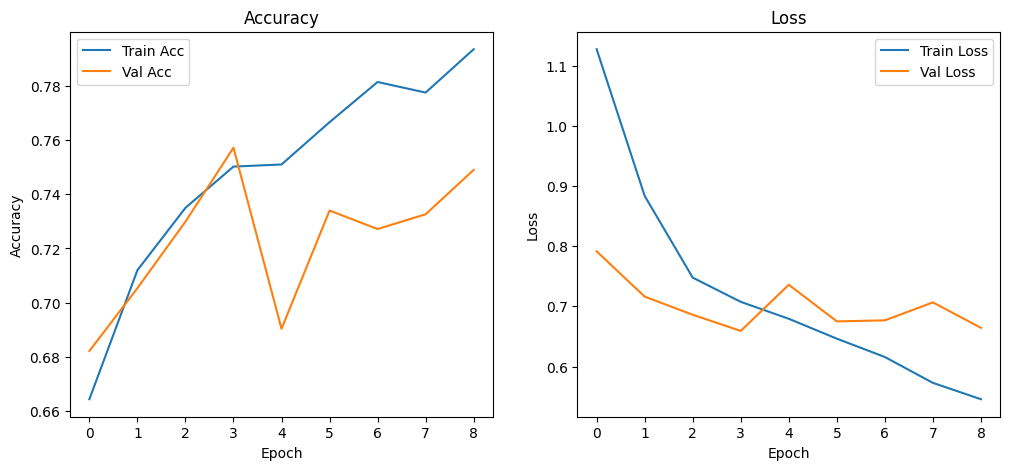

In [18]:
# Plot training & validation accuracy and loss
import matplotlib.pyplot as plt

def plot_history(history):
    plt.figure(figsize=(12,5))
    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    # Loss
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

plot_history(history)

12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 450ms/step
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       181
           1       0.43      0.49      0.46        37
           2       0.61      0.68      0.64       100
           3       0.38      0.16      0.22        19
           4       0.33      0.27      0.30        30

    accuracy                           0.73       367
   macro avg       0.54      0.51      0.51       367
weighted avg       0.72      0.73      0.72       367



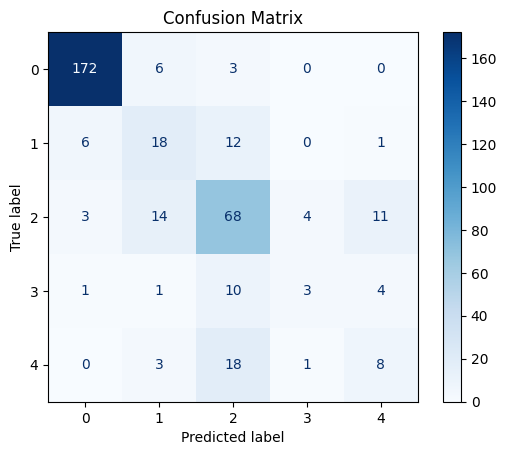

In [19]:
# Classification report and confusion matrix
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Get predictions for test set
y_true = test_df['diagnosis'].values
y_pred = model.predict(test_gen, verbose=1)
y_pred_labels = np.argmax(y_pred, axis=1) if y_pred.ndim > 1 else np.round(y_pred).astype(int)

# Classification report
print(classification_report(y_true, y_pred_labels))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()